In [ ]:
#| default_exp models.naive

In [ ]:
#| export
from __future__ import annotations
from typing import List, Optional, Callable, Tuple, Union
import numpy as np
import pandas as pd
import copy
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform)
from peshbeen.model_selection import SplitTimeSeries
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")

class naive:
    def __init__(
        self,
        target_col: str,
        season_period: Optional[int] = None,
        box_cox: Union[bool, float] = False,
        box_cox_biasadj: bool = False,
    ) -> None:
 
        """
        Naïve forecaster.
    
        Two modes controlled by ``season_period``:
    
        * **Non-seasonal** (``season_period=None``): every forecast step repeats
        the last observed value in the training series.
        * **Seasonal** (``season_period=m``): forecast values are taken from the
        last complete season and cycled forward — i.e. step ``h`` is predicted
        by ``y[T - m + ((h-1) % m)]``, where ``T`` is the last training index.
    
        Parameters
        ----------
        target_col : str
            Name of the target variable column.
        season_period : int or None, default None
            Seasonal period ``m``.  ``None`` selects the non-seasonal naïve method.  When provided and the training series is shorter than ``m``, ``forecast`` returns an array of ``NaN``.
        box_cox : bool or float, optional
            Whether to apply Box-Cox transformation to the target variable. If a float value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data.
        box_cox_biasadj : bool, default False
            Bias adjustment when inverting the manual Box-Cox on forecasts.
        
        Returns
        -------
        None
        """
 
        self.target_col  = target_col
        self.season_period = season_period
        if isinstance(box_cox, bool):
            self.box_cox = box_cox
            self.lamda = None
        elif isinstance(box_cox, (float, int)):
            self.box_cox = True
            self.lamda = box_cox
        self.biasadj       = box_cox_biasadj
 
        # ── placeholders set during fit ────────────────────────────────────────
        self.tuned_params   = None
        self.actuals        = None
        self.prob_forecasts = None
 
    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────
 
    def data_prep(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply preprocessing and return a cleaned DataFrame.
 
        Pipeline: manual Box-Cox → ``dropna`` → return target column only.
 
        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame containing the target column.
 
        Returns
        -------
        pd.DataFrame
        """
        dfc = df.copy()
        self.orig_target = dfc[self.target_col].values # store for generating in sample residuals later
        # ── manual Box-Cox ────────────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            self.trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero,
                box_cox_lmda=self.lamda,
            )
            dfc[self.target_col] = self.trans_data
 
        return dfc[[self.target_col]].dropna()
 
    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────
 
    def fit(self, df: pd.DataFrame) -> None:
        """
        Store the values needed for naïve forecasting.
 
        No statistical model is estimated.  ``fit`` simply applies
        ``data_prep`` and records the training series so that ``forecast``
        can replicate the correct naïve pattern.
 
        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target column.
 
        Returns
        -------
        None
        """
        model_df = self.data_prep(df)
        self.y   = model_df[self.target_col].to_numpy()

    # ─────────────────────────────────────────────────────────────────────────
    # predict_in_sample
    # ─────────────────────────────────────────────────────────────────────────

    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        # if .fit has not been called yet, error out
        if not hasattr(self, "y"):
            raise ValueError("Model has not been fitted yet. Call .fit() before predict_in_sample().")


        # residuals are the difference between the today and yesterday values in the transformed scale (after all transformations are applied in the correct order in data_prep)

        if self.season_period is not None:
            # for seasonal naive, the in-sample residuals are the difference between the value at time t and the value at time t-m (the last season)
             self.in_samp_resids = self.y - np.concatenate([np.repeat(np.nan, self.season_period), self.y[:-self.season_period]])
        else:
            # for non-seasonal naive, the in-sample residuals are the difference between the value at time t and the value at time t-1 (the last observed value)
            self.in_samp_resids = self.y - np.concatenate([np.repeat(np.nan, 1), self.y[:-1]])

        if not self.box_cox:
            self.fitted_values = self.orig_target + self.in_samp_resids
            
        else:
            bc_fitted= self.trans_data + self.in_samp_resids
            self.fitted_values = back_box_cox_transform(
                y_pred=bc_fitted, lmda=self.lamda,
                shift=self.is_zero)
            self.in_samp_resids = self.orig_target - self.fitted_values
        # add NaNs for the initial periods where fitted values are not available due to lag features        if fit_len < len(self.orig_target):
 
    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────
 
    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None,
    ) -> np.ndarray:
        
        """
        Generate naïve forecasts.
 
        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame or None
            Accepted for API consistency with other models but silently ignored — naïve forecasts do not use exogenous variables.
 
        Returns
        -------
        np.ndarray
            Forecast values of length `H`.
        """
        s = self.y  # already cleaned and Box-Cox transformed by data_prep
 
        if self.season_period is None:
            # ── Non-seasonal naïve: repeat the last observed value ─────────────
            if len(s) == 0:
                forecasts = np.full(H, np.nan)
            else:
                forecasts = np.full(H, s[-1])
 
        else:
            # ── Seasonal naïve: cycle the last season forward ──────────────────
            m = self.season_period
            if len(s) < m:
                forecasts = np.full(H, np.nan)
            else:
                last_season = s[-m:]
                repeats     = H // m
                remainder   = H % m
                forecasts   = np.tile(last_season, repeats)
                if remainder > 0:
                    forecasts = np.concatenate([forecasts, last_season[:remainder]])
 
        # ── non-negativity ────────────────────────────────────────────────────
        forecasts = np.array([max(0, x) for x in forecasts])
 
        # ── invert manual Box-Cox ─────────────────────────────────────────────
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj,
            )
 
        return forecasts
 
    def copy(self):
        return copy.deepcopy(self)
 
    # ─────────────────────────────────────────────────────────────────────────
    # CROSS-VALIDATION  (identical signature and logic to ets.cross_validate)
    # ─────────────────────────────────────────────────────────────────────────
 
    def cross_validate(
        self,
        df: pd.DataFrame,
        cv_split: int,
        test_size: int,
        metrics: List[Callable],
        step_size: int = 1,
        h_split_point: Optional[int] = None,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Run time-series cross-validation.
 
        Parameters
        ----------
        df : pd.DataFrame
            Full dataset.
        cv_split : int
            Number of CV folds.
        test_size : int
            Test window size per fold.
        metrics : list of callable
            Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
        step_size : int, default 1
            Step size to advance the test window each fold.
        h_split_point : int or None, default None
            Split the test window into two sub-horizons for separate short- and long-term evaluation.
 
        Returns
        -------
        overall_performance : pd.DataFrame and cv_predictions : pd.DataFrame
            Summary DataFrame with mean metric scores across folds, and (optionally) a fold-level DataFrame with true vs. predicted values for each fold.
        """
        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(
            n_splits=cv_split, test_size=test_size, step_size=step_size
        )
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}
 
        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])
 
            self.fit(train)
            bb_forecast = np.array(self.forecast(test_size, x_test))
 
            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, bb_forecast, train[self.target_col])
                else:
                    eval_val = m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)
 
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = (
                    bb_forecast[:h_split_point], bb_forecast[h_split_point:]
                )
                for m in metrics:
                    if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)
 
            split_results = {
                "cutoff": np.repeat(test.index[0], len(test)),
                "index":  test.index,
                "split":  np.repeat(f"fold_{idx + 1}", len(test)),
                "y_true": y_test,
                "y_pred": bb_forecast,
            }
            cv_df_ = pd.concat(
                [cv_df_, pd.DataFrame(split_results)], ignore_index=True
            )
 
        overall_performance = pd.DataFrame(
            [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics],
            columns=["eval_metric", "score"],
        )
 
        if h_split_point is not None and isinstance(h_split_point, int):
            perf_1_df = pd.DataFrame(
                [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics],
                columns=["eval_metric", f"score_before_{h_split_point}"],
            )
            perf_2_df = pd.DataFrame(
                [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics],
                columns=["eval_metric", f"score_after_{h_split_point}"],
            )
            overall_performance = (
                overall_performance
                .merge(perf_1_df, on="eval_metric")
                .merge(perf_2_df, on="eval_metric")
            )
        self.cv_summary = overall_performance
        return cv_df_

    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "naive"

In [ ]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import show_doc

In [ ]:
#| echo: false
docments(naive, full=True)
DocmentTbl(naive)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| target_col | str |  | Name of the target variable column. |
| season_period | Optional[int] | None | Seasonal period ``m``.  ``None`` selects the non-seasonal naïve method.  When provided and the training series is shorter than ``m``, ``forecast`` returns an array of ``NaN``. |
| box_cox | Union[bool, float] | False | Whether to apply Box-Cox transformation to the target variable. If a float value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data. |
| box_cox_biasadj | bool | False | Bias adjustment when inverting the manual Box-Cox on forecasts. |
| **Returns** | **None** |  |  |

In [ ]:
#| echo: false
show_doc(naive.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/naive.py#L102){target="_blank" style="float:right; font-size:smaller"}

### naive.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing the target column.
)->None:


```

*Store the values needed for naïve forecasting.*

No statistical model is estimated.  ``fit`` simply applies
``data_prep`` and records the training series so that ``forecast``
can replicate the correct naïve pattern.

In [ ]:
#| echo: false
DocmentTbl(naive.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing the target column. |
| **Returns** | **None** |  |

In [ ]:
#| echo: false
show_doc(naive.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/naive.py#L165){target="_blank" style="float:right; font-size:smaller"}

### naive.forecast

```python

def forecast(
    H:int, # Forecast horizon.
    exog:Optional[pd.DataFrame]=None, # Accepted for API consistency with other models but silently ignored — naïve forecasts do not use exogenous variables.
)->np.ndarray: # Forecast values of length `H`.


```

*Generate naïve forecasts.*

In [ ]:
#| echo: false
DocmentTbl(naive.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon. |
| exog | Optional[pd.DataFrame] | None | Accepted for API consistency with other models but silently ignored — naïve forecasts do not use exogenous variables. |
| **Returns** | **np.ndarray** |  | **Forecast values of length `H`.** |

In [ ]:
#| echo: false
show_doc(naive.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/naive.py#L227){target="_blank" style="float:right; font-size:smaller"}

### naive.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # Full dataset.
    cv_split:int, # Number of CV folds.
    test_size:int, # Test window size per fold.
    metrics:List[Callable], # Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
    step_size:int=1, # Step size to advance the test window each fold.
    h_split_point:Optional[int]=None, # Split the test window into two sub-horizons for separate short- and long-term evaluation.
)->Tuple[pd.DataFrame, pd.DataFrame]: # Summary DataFrame with mean metric scores across folds, and (optionally) a fold-level DataFrame with true vs. predicted values for each fold.


```

*Run time-series cross-validation.*

In [ ]:
#| echo: false
DocmentTbl(naive.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Full dataset. |
| cv_split | int |  | Number of CV folds. |
| test_size | int |  | Test window size per fold. |
| metrics | List[Callable] |  | Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores. |
| step_size | int | 1 | Step size to advance the test window each fold. |
| h_split_point | Optional[int] | None | Split the test window into two sub-horizons for separate short- and long-term evaluation. |
| **Returns** | **Tuple[pd.DataFrame, pd.DataFrame]** |  | **Summary DataFrame with mean metric scores across folds, and (optionally) a fold-level DataFrame with true vs. predicted values for each fold.** |

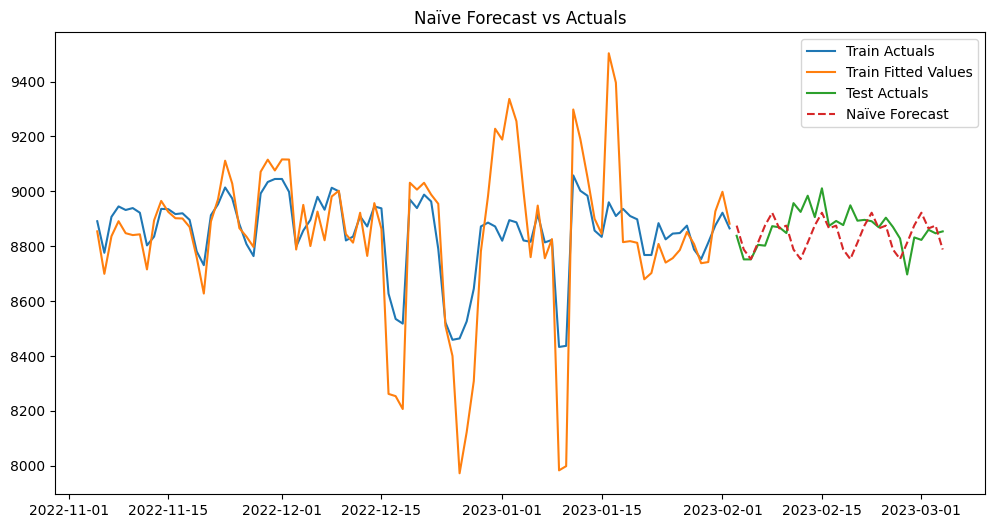

In [ ]:
#| hide

from peshbeen.datasets import load_wales_admissions
wales_admissions = load_wales_admissions()
wales_admissions["day_of_week"] = wales_admissions.index.dayofweek
wales_admissions["month"] = wales_admissions.index.month
# wales_admissions = pd.get_dummies(wales_admissions, columns=["day_of_week", "month"], drop_first=True, dtype=np.float32)
# split the data into train and test sets
train = wales_admissions[:-30]
test = wales_admissions[-30:]
from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
naive_model = naive(
    target_col="admissions",
    season_period=7,
    box_cox=0.5,
)
naive_model.fit(train)
naive_model.predict_in_sample()
naive_forecast = naive_model.forecast(30)

# plot the forecasts against the actuals
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(train.index[-90:], train["admissions"][-90:], label="Train Actuals")
plt.plot(train.index[-90:], naive_model.fitted_values[-90:], label="Train Fitted Values")
plt.plot(test.index, test["admissions"], label="Test Actuals")
plt.plot(test.index, naive_forecast, label="Naïve Forecast", linestyle="--")
plt.legend()
plt.title("Naïve Forecast vs Actuals")
plt.show()